In [52]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot style
plt.style.use("ggplot")

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [6]:
df = pd.read_csv(r"C:\Users\Asus\OneDrive\Desktop\ML_WORK\Sales Forecasting Dashboard\dataset.zip")

In [7]:
# Display the first 5 rows
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


### Observation

- Each row represents the weekly sales of a Walmart store.
- The dataset contains information about store ID, date, sales, holidays, and economic indicators.
- The target variable appears to be **Weekly_Sales**.

In [8]:
rows, columns = df.shape

print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")

Number of rows: 6435
Number of columns: 8


In [9]:
df.columns

Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')

### Observation

The dataset consists of:

- Store information
- Time information
- Sales information
- Economic indicators

These variables may influence weekly sales.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


### Observation

- The Date column is currently stored as an object.
- Weekly_Sales is numerical.(regression problem)
- Holiday_Flag is binary (0 or 1).
- Some columns may require datatype conversion.

In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,6435.0,2.300000e+01,12.988182,1.000,12.000,23.000000,3.400000e+01,4.500000e+01
Weekly_Sales,6435.0,1.046965e+06,564366.622054,209986.250,553350.105,960746.040000,1.420159e+06,3.818686e+06
Holiday_Flag,6435.0,6.993007e-02,0.255049,0.000,0.000,0.000000,0.000000e+00,1.000000e+00
Temperature,6435.0,6.066378e+01,18.444933,-2.060,47.460,62.670000,7.494000e+01,1.001400e+02
Fuel_Price,6435.0,3.358607e+00,0.459020,2.472,2.933,3.445000,3.735000e+00,4.468000e+00
CPI,6435.0,1.715784e+02,39.356712,126.064,131.735,182.616521,2.127433e+02,2.272328e+02
Unemployment,6435.0,7.999151e+00,1.875885,3.879,6.891,7.874000,8.622000e+00,1.431300e+01


In [20]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


### Observations

- The dataset contains 6,435 observations and 8 variables.
- No missing values were detected.
- The Date column is stored as an object and should be converted to datetime.
- Weekly Sales exhibit substantial variation across stores, suggesting that store-specific factors significantly influence sales.
- Economic indicators such as CPI and Unemployment vary considerably and may contribute to changes in sales over time.
- The wide range of temperatures indicates the dataset spans multiple seasons, which could affect purchasing behavior.

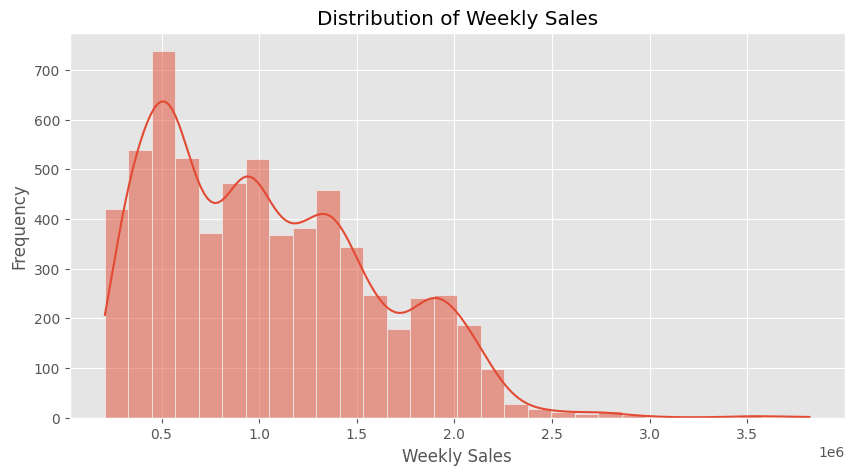

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(df["Weekly_Sales"], bins=30, kde=True)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

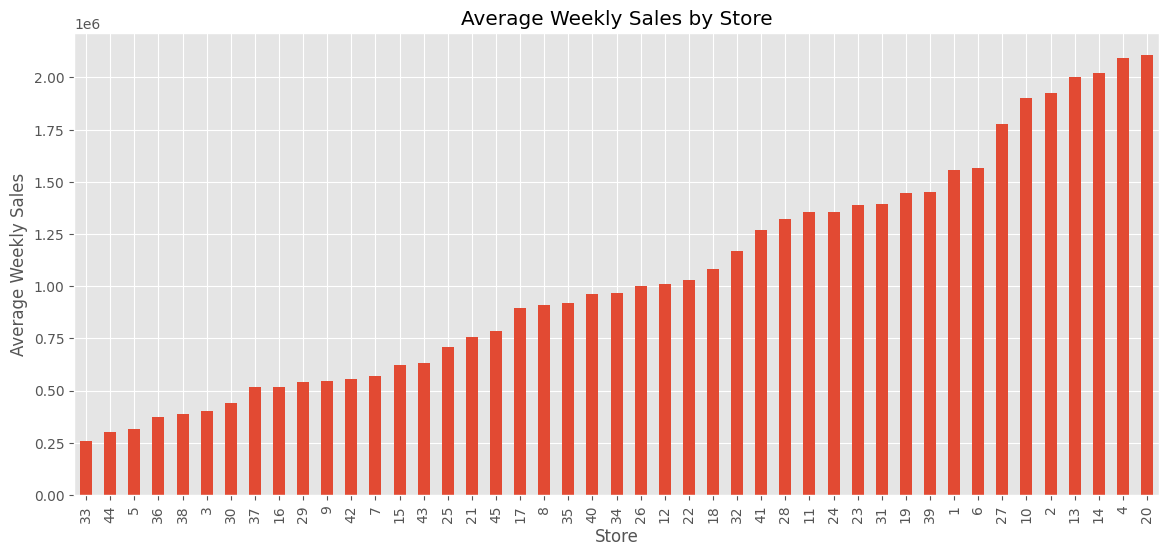

In [22]:
store_sales = df.groupby("Store")["Weekly_Sales"].mean().sort_values()

plt.figure(figsize=(14,6))
store_sales.plot(kind="bar")

plt.title("Average Weekly Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")

plt.show()

In [23]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

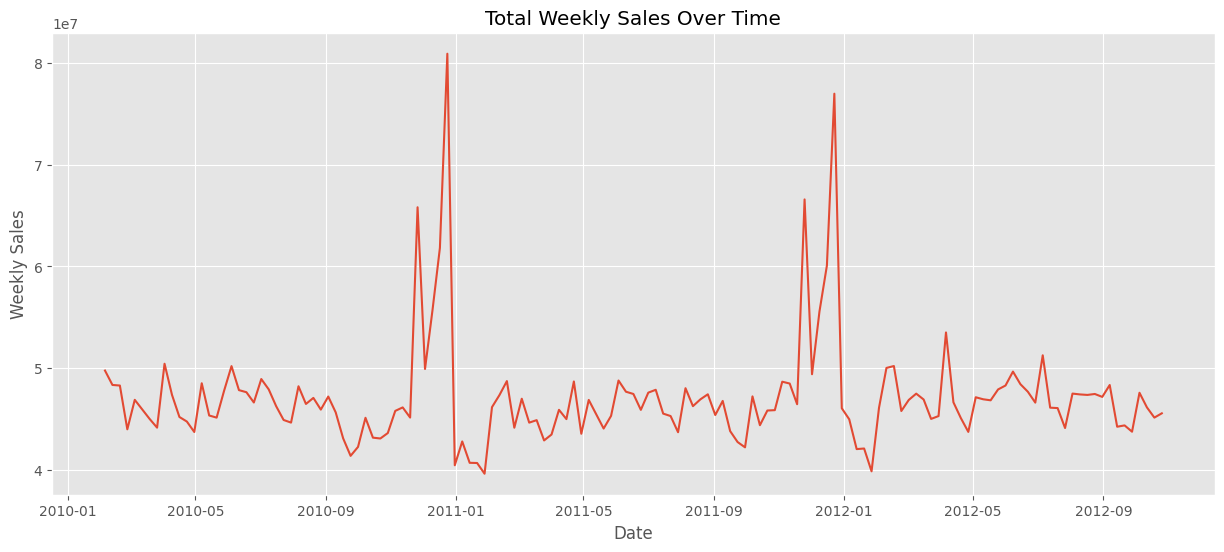

In [24]:
weekly_sales = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(15,6))
plt.plot(weekly_sales)

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")

plt.show()

### Observation

- Total weekly sales remain relatively stable throughout the observed period, generally ranging between $44 million and $50 million.
- Two prominent sales peaks appear near the end of each year, indicating recurring seasonal events.
- There is no significant long-term upward or downward trend.
- The recurring peaks suggest that holidays or major shopping events substantially increase weekly sales.

In [25]:
holiday_sales = df.groupby("Holiday_Flag")["Weekly_Sales"].mean()

holiday_sales

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

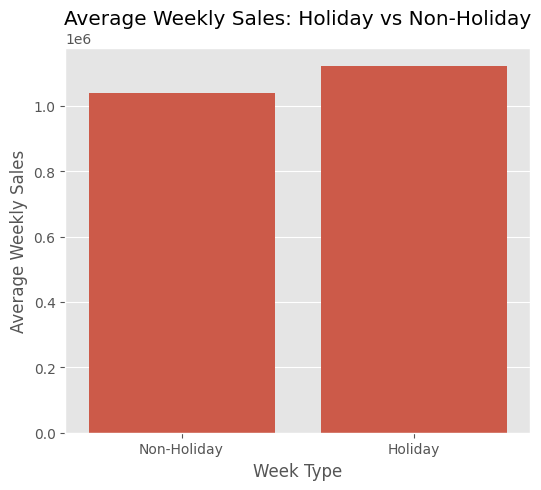

In [26]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=df,
    x="Holiday_Flag",
    y="Weekly_Sales",
    estimator="mean",
    errorbar=None
)

plt.xticks([0,1],["Non-Holiday","Holiday"])

plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Week Type")
plt.ylabel("Average Weekly Sales")

plt.show()

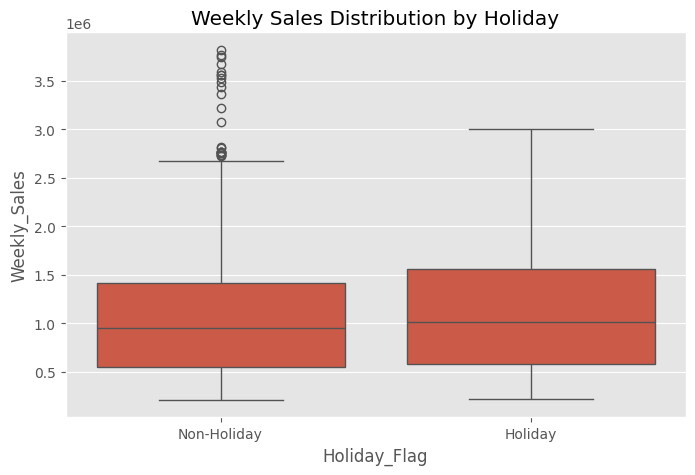

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Holiday_Flag",
    y="Weekly_Sales"
)

plt.xticks([0,1],["Non-Holiday","Holiday"])

plt.title("Weekly Sales Distribution by Holiday")

plt.show()

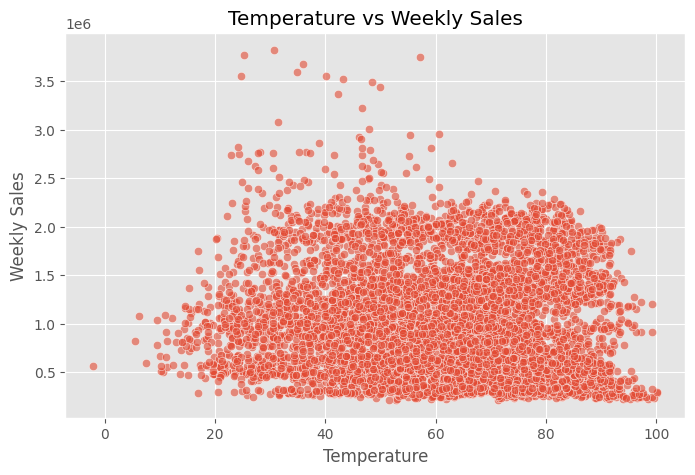

In [28]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Temperature",
    y="Weekly_Sales",
    alpha=0.6
)

plt.title("Temperature vs Weekly Sales")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")

plt.show()

### Observation

The scatter plot does not show a clear positive or negative relationship between temperature and weekly sales. Sales are widely distributed across all temperature values, suggesting a weak correlation.

### Business Insight

Customer spending remains relatively stable across different temperatures, indicating that temperature is not a primary driver of Walmart's weekly sales.

### ML Insight

Temperature is likely a weak predictive feature on its own, although it may still provide additional information when combined with other variables.

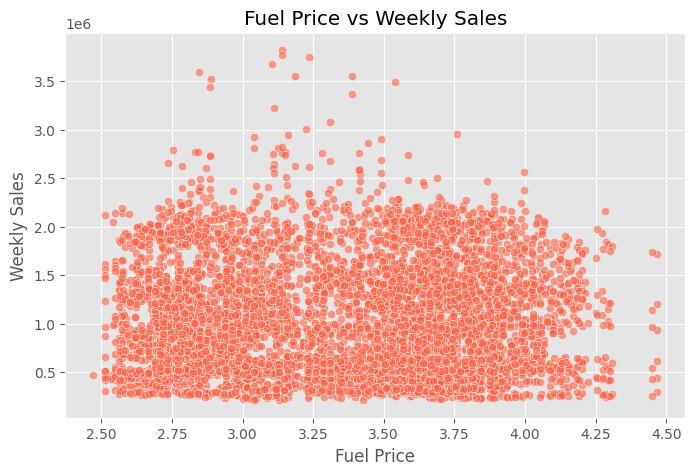

In [29]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Fuel_Price",
    y="Weekly_Sales",
    alpha=0.6,
    color="tomato"
)

plt.title("Fuel Price vs Weekly Sales")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")

plt.show()

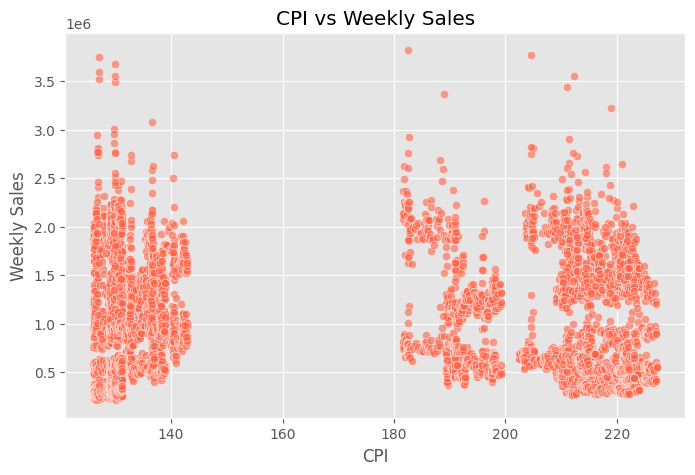

In [30]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="CPI",
    y="Weekly_Sales",
    alpha=0.6,
    color="tomato"
)

plt.title("CPI vs Weekly Sales")
plt.xlabel("CPI")
plt.ylabel("Weekly Sales")

plt.show()

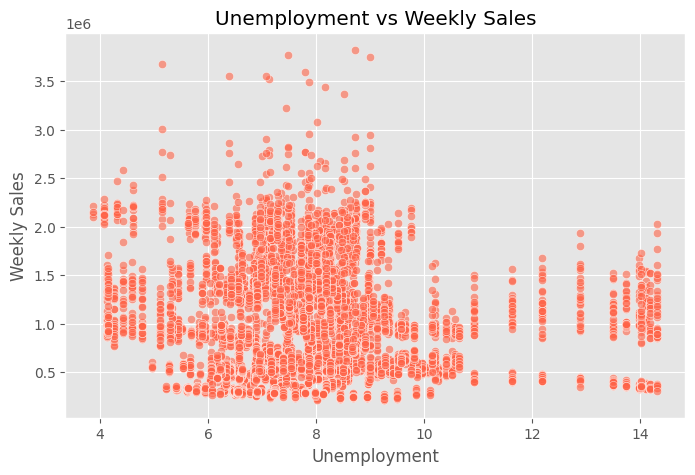

In [31]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Unemployment",
    y="Weekly_Sales",
    alpha=0.6,
    color="tomato"
)

plt.title("Unemployment vs Weekly Sales")
plt.xlabel("Unemployment")
plt.ylabel("Weekly Sales")

plt.show()

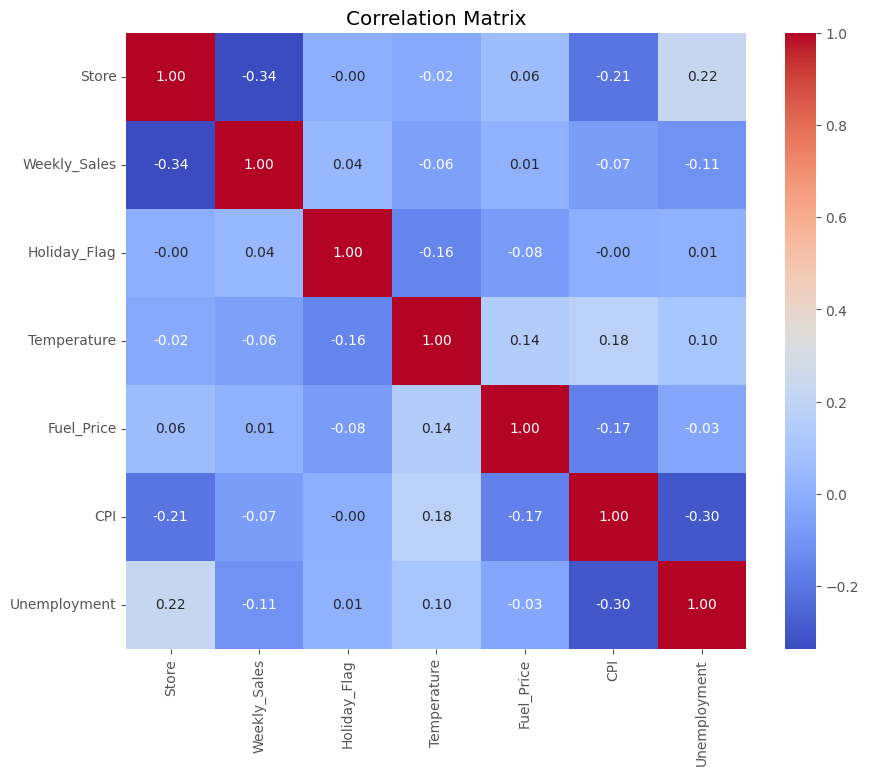

In [32]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

## Correlation Analysis

### Observation

- Store ID has the strongest correlation with Weekly Sales (-0.34).
- Unemployment shows a weak negative relationship (-0.11).
- Temperature, Fuel Price, CPI, and Holiday_Flag exhibit very weak linear correlations with Weekly Sales.
- No pair of input features shows a strong correlation, indicating low multicollinearity.

### Business Insight

Weekly sales are influenced by multiple factors rather than a single dominant variable. Individual economic indicators have limited linear relationships with sales.

### ML Insight

No feature should be removed based solely on correlation. Machine learning models, especially tree-based models like Random Forest, can capture complex and non-linear relationships that simple correlation cannot.

In [33]:
# Convert Date column to datetime

df["Date"] = pd.to_datetime(df["Date"])

In [35]:
# Extract date features

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter

In [36]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1


In [37]:
df.drop("Date", axis=1, inplace=True)

In [38]:
df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week,Quarter
0,1,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5,1
1,1,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6,1
2,1,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7,1
3,1,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8,1
4,1,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9,1


In [44]:
X = df.drop("Weekly_Sales", axis=1)
y = df["Weekly_Sales"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5148, 10)
X_test : (1287, 10)
y_train: (5148,)
y_test : (1287,)


In [45]:
from sklearn.linear_model import LinearRegression

# Create the model
lr = LinearRegression()

# Train the model
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
y_pred = lr.predict(X_test)
results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

results.head(10)

,Actual Sales,Predicted Sales
0,1138800.32,1.193955e+06
1,1304850.67,1.119052e+06
2,1769296.25,1.269643e+06
3,1077640.13,1.190047e+06
4,428851.99,7.286697e+05
5,1004523.59,9.227643e+05
6,1523410.71,9.765013e+05
7,1014898.78,1.173826e+06
8,1955896.59,9.655422e+05
9,958667.23,1.220377e+06


In [54]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 433270.43422742333
RMSE: 521853.28045206115
R² Score: 0.15465780648429317


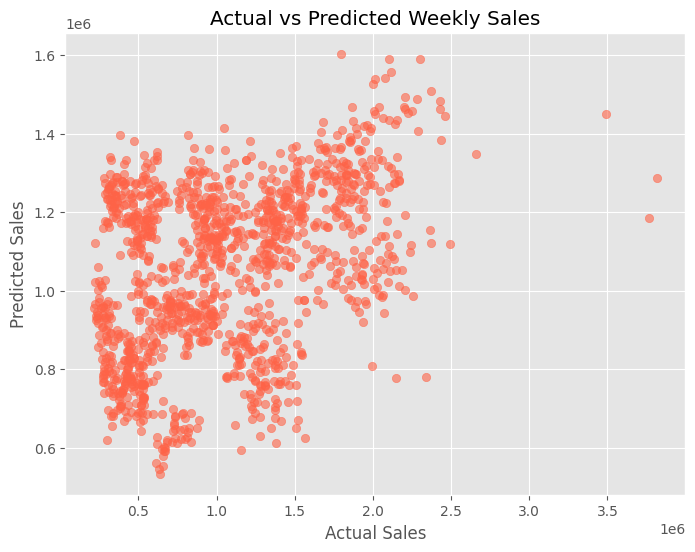

In [55]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6, color="tomato")

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Weekly Sales")

plt.show()

In [58]:
from sklearn.tree import DecisionTreeRegressor

# Create the model
dt = DecisionTreeRegressor(random_state=42)

# Train
dt.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [60]:
y_pred_dt = dt.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("MAE :", mae_dt)
print("RMSE:", rmse_dt)
print("R² :", r2_dt)

Decision Tree Results
MAE : 75320.22606837608
RMSE: 136002.41026105624
R² : 0.9425845304478425


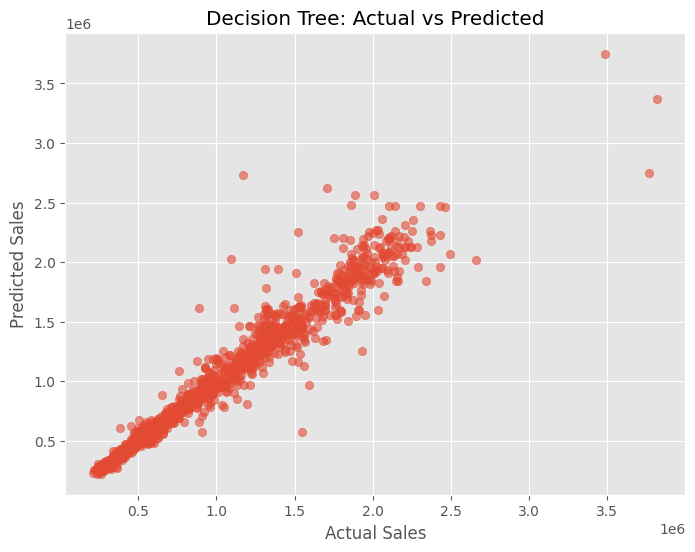

In [61]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_dt, alpha=0.6)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Decision Tree: Actual vs Predicted")

plt.show()

In [62]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [63]:
# Make predictions
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² :", r2_rf)

Random Forest Results
MAE : 62143.851399922285
RMSE: 114410.74277651502
R² : 0.9593678951047735


In [64]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Store,0.663322
4,CPI,0.153702
5,Unemployment,0.104246
8,Week,0.049739
2,Temperature,0.012988
3,Fuel_Price,0.010162
7,Month,0.002897
1,Holiday_Flag,0.001740
6,Year,0.000967
9,Quarter,0.000238


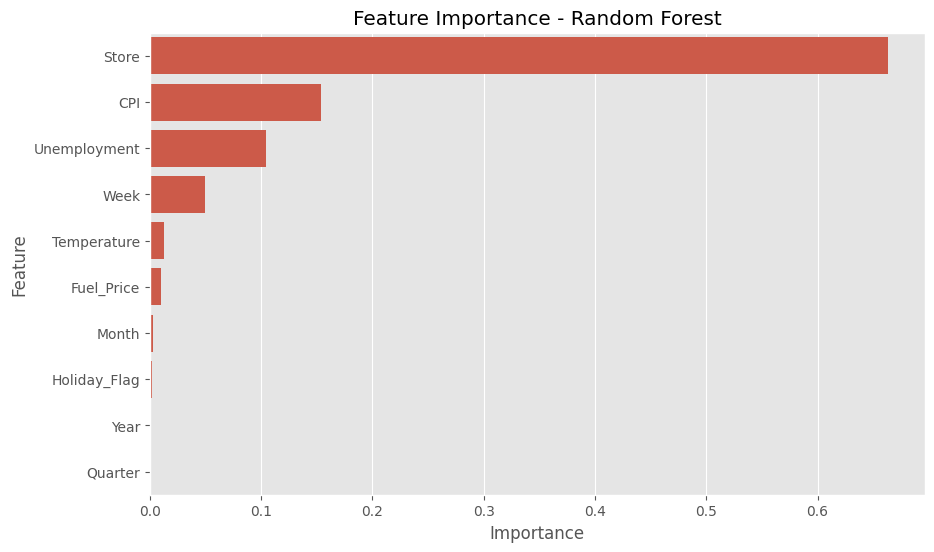

In [65]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")

plt.show()

# 🌲 Random Forest Regressor

## Objective

The objective of this model is to improve the prediction accuracy of weekly Walmart sales by capturing the complex and non-linear relationships between the input features and the target variable.

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees and averages their predictions, making it more accurate and less prone to overfitting than a single Decision Tree.

---

## Model Training

The Random Forest Regressor was trained using the training dataset generated from the Train-Test Split.

**Model Parameters**

- Number of Trees (n_estimators): 100
- Random State: 42

---

## Model Evaluation

| Metric | Value |
|---------|-------|
| MAE | 62,143.85 |
| RMSE | 114,410.74 |
| R² Score | 0.959 |

---

## Interpretation

The Random Forest model achieved the best performance among all tested models.

- The MAE indicates that the model's predictions differ from the actual weekly sales by approximately **$62,144** on average.
- The RMSE is relatively low, suggesting that the model produces few large prediction errors.
- The R² Score of **0.959** means that the model explains approximately **95.9%** of the variation in weekly sales.

---

## Business Insight

Weekly sales are affected by multiple interacting factors such as the store, seasonality, holidays, and economic indicators.

Random Forest successfully captures these complex relationships, resulting in highly accurate predictions.

---

## Conclusion

After comparing multiple regression models, **Random Forest Regressor** was selected as the final model because it achieved:

- Lowest MAE
- Lowest RMSE
- Highest R² Score

Therefore, Random Forest is the most suitable model for predicting Walmart weekly sales in this project.

In [66]:
import joblib

joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [67]:
loaded_model = joblib.load("random_forest_model.pkl")

In [68]:
loaded_model.predict(X_test[:5])

array([1155790.4892, 1425245.0865, 1829023.7222,  960710.3523,
        432218.9488])

In [69]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        mae_dt,
        mae_rf
    ],
    "RMSE": [
        rmse,
        rmse_dt,
        rmse_rf
    ],
    "R2 Score": [
        r2,
        r2_dt,
        r2_rf
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,433270.434227,521853.280452,0.154658
1,Decision Tree,75320.226068,136002.410261,0.942585
2,Random Forest,62143.851400,114410.742777,0.959368
